# Building and Differential-Testing a Regex Engine

This notebook implements a small regular-expression engine without using regex internally, proves its supported semantics against Python's `re.fullmatch`, and measures DFA behavior against backtracking.

- **Phase 0:** empirically probe the Pyodide runtime
- **Phase 1:** build tokenizer → AST → Thompson NFA → subset DFA
- **Phase 2:** generate, shrink, diagnose, patch, and require 20,000 consecutive agreements
- **Phase 3:** benchmark matching, compilation, and DFA state growth
- **Phase 4:** write and print `REPORT.md`

## Phase 0 — Runtime probe

We start with identity, recursion depth, package imports, filesystem writes, system-module availability, and a fixed integer-loop timing. Failures are retained as findings rather than hidden.

In [22]:
import sys, time, traceback, importlib, os

progress = {
    "phase0": "in_progress",
    "phase1": "pending",
    "phase2": "pending",
    "phase3": "pending",
    "phase4": "pending",
    "consecutive_agreements": 0,
    "bugs_found": 0,
}

probe_rows = []
probe_rows.append(("Python version", True, sys.version.replace("\n", " ")))
probe_rows.append(("Platform", True, sys.platform))
probe_rows.append(("Recursion limit", True, str(sys.getrecursionlimit())))
print("Initial runtime identity recorded.")
probe_rows

Initial runtime identity recorded.


[('Python version', True, '3.13.2 (main, May  7 2026, 08:28:34) [Clang 21.0.0git (https:/github.com/llvm/llvm-project 2f05451198e2f222ec66cec489'), ('Platform', True, 'emscripten'), ('Recursion limit', True, '3000')]

### Scientific stack and package manager

Each import is attempted independently so one unavailable package cannot mask the others. For `micropip`, successful import plus inspection of its install API establishes that the in-browser package manager is present; no network install is needed for this project.

In [2]:
package_modules = ["numpy", "matplotlib", "scipy", "sympy", "micropip"]
package_findings = {}

for name in package_modules:
    try:
        module = importlib.import_module(name)
        version = getattr(module, "__version__", "available")
        detail = f"imported; version={version}"
        if name == "micropip":
            detail += f"; install_callable={callable(getattr(module, 'install', None))}"
        package_findings[name] = (True, detail)
        print(f"PASS {name}: {detail}")
    except Exception:
        package_findings[name] = (False, "import failed")
        print(f"FAIL {name}")
        traceback.print_exc()

for name, (ok, detail) in package_findings.items():
    probe_rows.append((f"Import {name}", ok, detail))
package_findings

FAIL numpy


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cxzxeioo", line 6, in <module>
    module = importlib.import_module(name)
  File "/lib/python313.zip/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'numpy'

FAIL matplotlib


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cxzxeioo", line 6, in <module>
    module = importlib.import_module(name)
  File "/lib/python313.zip/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'matplotlib'

FAIL scipy


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cxzxeioo", line 6, in <module>
    module = importlib.import_module(name)
  File "/lib/python313.zip/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'scipy'

FAIL sympy


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cxzxeioo", line 6, in <module>
    module = importlib.import_module(name)
  File "/lib/python313.zip/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'sympy'

PASS micropip: imported; version=0.11.1; install_callable=True


{'numpy': (False, 'import failed'), 'matplotlib': (False, 'import failed'), 'scipy': (False, 'import failed'), 'sympy': (False, 'import failed'), 'micropip': (True, 'imported; version=0.11.1; install_callable=True')}

### Package fallback through `micropip`

The first probe showed the modules are not initially importable. We now use the available package manager and then retry imports, retaining installation errors as runtime evidence.

In [3]:
import micropip

install_targets = ["numpy", "matplotlib", "scipy", "sympy"]
try:
    started = time.perf_counter()
    await micropip.install(install_targets)
    elapsed = time.perf_counter() - started
    print(f"micropip installation call completed in {elapsed:.3f} s")
except Exception:
    print("micropip installation failed with this traceback:")
    traceback.print_exc()

post_install = {}
for name in install_targets:
    try:
        module = importlib.import_module(name)
        post_install[name] = (True, getattr(module, "__version__", "available"))
        print(f"PASS after micropip: {name} {post_install[name][1]}")
    except Exception:
        post_install[name] = (False, "still unavailable")
        print(f"FAIL after micropip: {name}")
        traceback.print_exc()

for i, (label, _, _) in enumerate(probe_rows):
    short = label.removeprefix("Import ")
    if short in post_install:
        ok, version = post_install[short]
        probe_rows[i] = (label, ok, f"direct import failed; micropip retry: {version}")
post_install

micropip installation call completed in 7.921 s
PASS after micropip: numpy 2.2.5
PASS after micropip: matplotlib 3.8.4
PASS after micropip: scipy 1.14.1
PASS after micropip: sympy 1.13.3


{'numpy': (True, '2.2.5'), 'matplotlib': (True, '3.8.4'), 'scipy': (True, '1.14.1'), 'sympy': (True, '1.13.3')}

### Filesystem writability

A write/read/delete round trip in the current working directory tests the virtual filesystem behavior needed for `myre.py` and `REPORT.md`.

In [4]:
probe_path = "_runtime_write_probe.txt"
try:
    payload = "pyodide filesystem round trip\n"
    with open(probe_path, "w", encoding="utf-8") as handle:
        written = handle.write(payload)
    with open(probe_path, "r", encoding="utf-8") as handle:
        recovered = handle.read()
    os.remove(probe_path)
    fs_ok = recovered == payload and written == len(payload) and not os.path.exists(probe_path)
    fs_detail = f"write/read/delete round trip; cwd={os.getcwd()}"
    print(f"PASS filesystem: {fs_detail}")
except Exception:
    fs_ok = False
    fs_detail = "round trip failed"
    print("FAIL filesystem")
    traceback.print_exc()
probe_rows.append(("Writable filesystem", fs_ok, fs_detail))
{"writable": fs_ok, "detail": fs_detail}

PASS filesystem: write/read/delete round trip; cwd=/home/pyodide


{'writable': True, 'detail': 'write/read/delete round trip; cwd=/home/pyodide'}

### Concurrency and socket probes

Importability alone can be misleading under WebAssembly. We attempt one tiny thread, query multiprocessing start methods, and create a socket object without making a network connection.

In [5]:
system_probe_results = {}

try:
    import threading
    marker = []
    thread = threading.Thread(target=lambda: marker.append("ran"))
    thread.start()
    thread.join(timeout=1.0)
    ok = marker == ["ran"] and not thread.is_alive()
    system_probe_results["threading"] = (ok, "module imports; tiny thread ran" if ok else "module imports; tiny thread did not complete")
    print("threading:", system_probe_results["threading"])
except Exception as exc:
    system_probe_results["threading"] = (False, f"unusable: {type(exc).__name__}: {exc}")
    print("threading traceback:")
    traceback.print_exc()

try:
    import multiprocessing as mp
    methods = mp.get_all_start_methods()
    system_probe_results["multiprocessing"] = (True, f"module imports; advertised start methods={methods}")
    print("multiprocessing:", system_probe_results["multiprocessing"])
except Exception as exc:
    system_probe_results["multiprocessing"] = (False, f"unavailable: {type(exc).__name__}: {exc}")
    print("multiprocessing traceback:")
    traceback.print_exc()

try:
    import socket
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.close()
    system_probe_results["socket"] = (True, "module imports; socket object create/close succeeded; connectivity not claimed")
    print("socket:", system_probe_results["socket"])
except Exception as exc:
    system_probe_results["socket"] = (False, f"object creation failed: {type(exc).__name__}: {exc}")
    print("socket traceback:")
    traceback.print_exc()

for name, (ok, detail) in system_probe_results.items():
    probe_rows.append((name, ok, detail))
system_probe_results

threading traceback:


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cutgflc9", line 7, in <module>
    thread.start()
    ~~~~~~~~~~~~^^
  File "/lib/python313.zip/threading.py", line 973, in start
    _start_joinable_thread(self._bootstrap, handle=self._handle,
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                           daemon=self.daemon)
                           ^^^^^^^^^^^^^^^^^^^
RuntimeError: can't start new thread

multiprocessing: (True, "module imports; advertised start methods=['fork', 'spawn', 'forkserver']")
socket: (True, 'module imports; socket object create/close succeeded; connectivity not claimed')


{'threading': (False, "unusable: RuntimeError: can't start new thread"), 'multiprocessing': (True, "module imports; advertised start methods=['fork', 'spawn', 'forkserver']"), 'socket': (True, 'module imports; socket object create/close succeeded; connectivity not claimed')}

### Multiprocessing functionality and scalar speed

We test actual child startup with a one-second bound, then time a deterministic 2,000,000-iteration integer loop. The engine will remain single-process regardless, since process startup is unnecessary overhead here.

In [6]:
def _noop_child():
    return None

mp_functional = False
try:
    child = mp.Process(target=_noop_child)
    child.start()
    child.join(timeout=1.0)
    if child.is_alive():
        print("Child remained alive after timeout; terminating.")
        child.terminate()
        child.join(timeout=1.0)
        raise RuntimeError("child did not finish within one second")
    mp_functional = child.exitcode == 0
    mp_detail = f"child start/join completed; exitcode={child.exitcode}"
    print("multiprocessing functional test:", mp_detail)
except Exception as exc:
    mp_detail = f"process creation unusable: {type(exc).__name__}: {exc}"
    print("multiprocessing functional-test traceback:")
    traceback.print_exc()

# Replace the import-only finding with the stronger functional result.
for i, (label, _, _) in enumerate(probe_rows):
    if label == "multiprocessing":
        probe_rows[i] = (label, mp_functional, mp_detail)

LOOP_N = 2_000_000
accumulator = 0
started = time.perf_counter()
for i in range(LOOP_N):
    accumulator = (accumulator + i) & 0xFFFFFFFF
loop_seconds = time.perf_counter() - started
loop_rate = LOOP_N / loop_seconds
probe_rows.append(("Integer-loop speed", True, f"{LOOP_N:,} iterations in {loop_seconds:.4f} s ({loop_rate:,.0f} iter/s); checksum={accumulator}"))
print(f"Loop: {LOOP_N:,} iterations in {loop_seconds:.4f} s; checksum={accumulator}")
{"multiprocessing_functional": mp_functional, "loop_seconds": loop_seconds, "iterations_per_second": loop_rate}

multiprocessing functional-test traceback:


Traceback (most recent call last):
  File "kernel://nbmtly0af42vdn/cq3norav", line 7, in <module>
    child.start()
    ~~~~~~~~~~~^^
  File "/lib/python313.zip/multiprocessing/process.py", line 121, in start
    self._popen = self._Popen(self)
                  ~~~~~~~~~~~^^^^^^
  File "/lib/python313.zip/multiprocessing/context.py", line 224, in _Popen
    return _default_context.get_context().Process._Popen(process_obj)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^
  File "/lib/python313.zip/multiprocessing/context.py", line 282, in _Popen
    return Popen(process_obj)
  File "/lib/python313.zip/multiprocessing/popen_fork.py", line 20, in __init__
    self._launch(process_obj)
    ~~~~~~~~~~~~^^^^^^^^^^^^^
  File "/lib/python313.zip/multiprocessing/popen_fork.py", line 67, in _launch
    self.pid = os.fork()
               ~~~~~~~^^
OSError: [Errno 52] Function not implemented

Loop: 2,000,000 iterations in 0.3092 s; checksum=2839207360


{'multiprocessing_functional': False, 'loop_seconds': 0.3091999999999757, 'iterations_per_second': 6468305.304010857}

### Phase 0 findings

“Available” means the tested operation succeeded, not merely that a name exists. In particular, socket object construction works but connectivity is not claimed, while thread/process creation was directly disproved.

In [7]:
header = ("Capability", "Available", "Observed detail")
widths = [len(x) for x in header]
for label, ok, detail in probe_rows:
    values = (label, "yes" if ok else "no", detail)
    widths = [max(widths[i], len(str(values[i]))) for i in range(3)]

def format_row(values):
    return " | ".join(str(values[i]).ljust(widths[i]) for i in range(3))

print(format_row(header))
print("-+-".join("-" * width for width in widths))
for label, ok, detail in probe_rows:
    print(format_row((label, "yes" if ok else "no", detail)))

progress["phase0"] = "complete"
progress["phase1"] = "in_progress"
print("\nprogress =", progress)

Capability          | Available | Observed detail                                                                                                      
--------------------+-----------+----------------------------------------------------------------------------------------------------------------------
Python version      | yes       | 3.13.2 (main, May  7 2026, 08:28:34) [Clang 21.0.0git (https:/github.com/llvm/llvm-project 2f05451198e2f222ec66cec489
Platform            | yes       | emscripten                                                                                                           
Recursion limit     | yes       | 3000                                                                                                                 
Import numpy        | yes       | direct import failed; micropip retry: 2.2.5                                                                          
Import matplotlib   | yes       | direct import failed; micropip retry: 3.8.4           

## Phase 1 — Engine architecture

The public path is `tokenize → parse → Thompson NFA → lazy subset DFA → fullmatch`. Assertions remain zero-width NFA edges evaluated during epsilon closure; all character consumption goes through explicit predicates.

### Tokens, AST nodes, and character classes

The tokenizer resolves escapes and classes without regex. Character classes store literal code points and inclusive ranges, with optional leading-`^` negation.

In [23]:
myre_source_parts = []
myre_source_parts.append(r'''"""A small regex engine: tokenizer, parser, Thompson NFA, and lazy DFA."""
from dataclasses import dataclass
from typing import Any


class RegexError(ValueError):
    pass


@dataclass(frozen=True)
class Token:
    kind: str
    value: Any = None
    pos: int = 0


@dataclass(frozen=True)
class Node:
    kind: str
    value: Any = None
    children: tuple = ()


@dataclass(frozen=True)
class ClassSpec:
    singles: frozenset
    ranges: tuple
    negated: bool = False

    def matches(self, ch):
        inside = ch in self.singles or any(lo <= ch < hi for lo, hi in self.ranges)
        return not inside if self.negated else inside


_ESCAPE_MAP = {"n": "\n", "t": "\t", "r": "\r", "f": "\f", "v": "\v", "a": "\a"}
_META = set(".*+?|()[]^$\\")


def _escaped(pattern, index):
    if index + 1 >= len(pattern):
        raise RegexError(f"trailing backslash at position {index}")
    code = pattern[index + 1]
    if code in _ESCAPE_MAP:
        return _ESCAPE_MAP[code], index + 2
    if code.isalnum():
        raise RegexError(f"unsupported escape \\{code} at position {index}")
    return code, index + 2


def _class_token(pattern, start):
    i = start + 1
    negated = i < len(pattern) and pattern[i] == "^"
    if negated:
        i += 1
    raw = []
    first = True
    while i < len(pattern):
        if pattern[i] == "]" and not first:
            break
        if pattern[i] == "\\":
            ch, i = _escaped(pattern, i)
            raw.append((ch, True))
        else:
            raw.append((pattern[i], False))
            i += 1
        first = False
    if i >= len(pattern) or pattern[i] != "]":
        raise RegexError(f"unterminated character class at position {start}")
    if not raw:
        raise RegexError(f"empty character class at position {start}")
    singles, ranges = set(), []
    j = 0
    while j < len(raw):
        if j + 2 < len(raw) and raw[j + 1] == ("-", False):
            lo, hi = raw[j][0], raw[j + 2][0]
            if ord(lo) > ord(hi):
                raise RegexError(f"descending range {lo}-{hi}")
            ranges.append((lo, hi))
            j += 3
        else:
            singles.add(raw[j][0])
            j += 1
    return Token("CLASS", ClassSpec(frozenset(singles), tuple(ranges), negated), start), i + 1


def tokenize(pattern):
    tokens = []
    single = {".": "DOT", "*": "STAR", "+": "PLUS", "?": "QMARK",
              "|": "ALT", "(": "LPAREN", ")": "RPAREN", "^": "BOL", "$": "EOL"}
    i = 0
    while i < len(pattern):
        ch = pattern[i]
        if ch == "\\":
            value, i = _escaped(pattern, i)
            tokens.append(Token("LIT", value, i - 2))
        elif ch == "[":
            token, i = _class_token(pattern, i)
            tokens.append(token)
        elif ch in single:
            tokens.append(Token(single[ch], None, i))
            i += 1
        else:
            tokens.append(Token("LIT", ch, i))
            i += 1
    tokens.append(Token("EOF", None, len(pattern)))
    return tokens
''')

print(f"Source part 1: {len(myre_source_parts[0].splitlines())} lines")
print("First definitions:", [line for line in myre_source_parts[0].splitlines() if line.startswith(("class ", "def "))][:8])

Source part 1: 106 lines
First definitions: ['class RegexError(ValueError):', 'class Token:', 'class Node:', 'class ClassSpec:', 'def _escaped(pattern, index):', 'def _class_token(pattern, start):', 'def tokenize(pattern):']


### Recursive-descent parser

Empty concatenations are valid so patterns such as `a|` match Python. Repeated postfix operators such as `a**` are rejected rather than assigned an invented meaning.

In [24]:
myre_source_parts.append(r'''

class Parser:
    def __init__(self, tokens):
        self.tokens = tokens
        self.index = 0

    @property
    def current(self):
        return self.tokens[self.index]

    def take(self, kind=None):
        token = self.current
        if kind is not None and token.kind != kind:
            raise RegexError(f"expected {kind}, found {token.kind} at position {token.pos}")
        self.index += 1
        return token

    def parse(self):
        node = self.alternation()
        if self.current.kind != "EOF":
            raise RegexError(f"unexpected {self.current.kind} at position {self.current.pos}")
        return node

    def alternation(self):
        branches = [self.concatenation()]
        while self.current.kind == "ALT":
            self.take("ALT")
            branches.append(self.concatenation())
        return branches[0] if len(branches) == 1 else Node("ALT", children=tuple(branches))

    def concatenation(self):
        parts = []
        while self.current.kind not in {"ALT", "RPAREN", "EOF"}:
            parts.append(self.repetition())
        if not parts:
            return Node("EMPTY")
        return parts[0] if len(parts) == 1 else Node("CONCAT", children=tuple(parts))

    def repetition(self):
        atom = self.atom()
        if self.current.kind in {"STAR", "PLUS", "QMARK"}:
            quantifier = self.take().kind
            if self.current.kind in {"STAR", "PLUS", "QMARK"}:
                raise RegexError(f"multiple repeat at position {self.current.pos}")
            return Node(quantifier, children=(atom,))
        return atom

    def atom(self):
        token = self.current
        if token.kind == "LIT":
            self.take()
            return Node("LIT", token.value)
        if token.kind == "DOT":
            self.take()
            return Node("DOT")
        if token.kind == "CLASS":
            self.take()
            return Node("CLASS", token.value)
        if token.kind == "BOL":
            self.take()
            return Node("BOL")
        if token.kind == "EOL":
            self.take()
            return Node("EOL")
        if token.kind == "LPAREN":
            opening = self.take()
            child = self.alternation()
            if self.current.kind != "RPAREN":
                raise RegexError(f"unclosed group at position {opening.pos}")
            self.take("RPAREN")
            return Node("GROUP", children=(child,))
        if token.kind == "RPAREN":
            raise RegexError(f"unmatched ')' at position {token.pos}")
        if token.kind in {"STAR", "PLUS", "QMARK"}:
            raise RegexError(f"nothing to repeat at position {token.pos}")
        raise RegexError(f"unexpected token {token.kind} at position {token.pos}")


def parse(pattern):
    return Parser(tokenize(pattern)).parse()
''')

parser_lines = myre_source_parts[-1].splitlines()
print(f"Source part 2: {len(parser_lines)} lines")
print("Parser methods:", [line.strip().split("(")[0] for line in parser_lines if line.startswith("    def ")])

Source part 2: 81 lines
Parser methods: ['def __init__', 'def current', 'def take', 'def parse', 'def alternation', 'def concatenation', 'def repetition', 'def atom']


### Thompson NFA construction

Transitions are tagged as epsilon, assertions, literals, dot, or class predicates. Thompson construction creates a fragment `(start, end)` for each AST node and joins fragments only with epsilon edges.

In [25]:
myre_source_parts.append(r'''

@dataclass
class NFA:
    transitions: list
    start: int
    accept: int


class NFABuilder:
    def __init__(self):
        self.transitions = []

    def state(self):
        index = len(self.transitions)
        self.transitions.append([])
        return index

    def edge(self, source, kind, value, target):
        self.transitions[source].append((kind, value, target))

    def build(self, node):
        kind = node.kind
        if kind in {"EMPTY", "LIT", "DOT", "CLASS", "BOL", "EOL"}:
            start, end = self.state(), self.state()
            edge_kind = "EPS" if kind == "EMPTY" else kind
            self.edge(start, edge_kind, node.value, end)
            return start, end
        if kind == "GROUP":
            return self.build(node.children[0])
        if kind == "CONCAT":
            first_start, previous_end = self.build(node.children[0])
            for child in node.children[1:]:
                child_start, child_end = self.build(child)
                self.edge(previous_end, "EPS", None, child_start)
                previous_end = child_end
            return first_start, previous_end
        if kind == "ALT":
            start, end = self.state(), self.state()
            for child in node.children:
                child_start, child_end = self.build(child)
                self.edge(start, "EPS", None, child_start)
                self.edge(child_end, "EPS", None, end)
            return start, end
        if kind in {"STAR", "PLUS", "QMARK"}:
            start, end = self.state(), self.state()
            child_start, child_end = self.build(node.children[0])
            if kind in {"STAR", "QMARK"}:
                self.edge(start, "EPS", None, end)
            self.edge(start, "EPS", None, child_start)
            if kind in {"STAR", "PLUS"}:
                self.edge(child_end, "EPS", None, child_start)
            self.edge(child_end, "EPS", None, end)
            return start, end
        raise RegexError(f"unknown AST node {kind}")


def to_nfa(ast):
    builder = NFABuilder()
    start, accept = builder.build(ast)
    return NFA(builder.transitions, start, accept)
''')

nfa_lines = myre_source_parts[-1].splitlines()
print(f"Source part 3: {len(nfa_lines)} lines")
print("Thompson cases:", ["atomic", "group", "concat", "alternation", "star/plus/question"])

Source part 3: 61 lines
Thompson cases: ['atomic', 'group', 'concat', 'alternation', 'star/plus/question']


### Lazy subset construction and public API

Unicode makes eager enumeration of every possible input symbol impractical. This DFA therefore performs standard subset construction lazily for characters actually encountered and records every resulting subset in `state_count`.

In [26]:
myre_source_parts.append(r'''

class DFA:
    def __init__(self, nfa):
        self.nfa = nfa
        self.subsets = {}
        self.transition_cache = {}

    def _register(self, states):
        states = frozenset(states)
        if states not in self.subsets:
            self.subsets[states] = len(self.subsets)
        return states

    def _closure(self, states, position, text):
        closed = set(states)
        stack = list(states)
        while stack:
            state = stack.pop()
            for kind, value, target in self.nfa.transitions[state]:
                enabled = (kind == "EPS" or
                           (kind == "BOL" and position == 0) or
                           (kind == "EOL" and position == len(text)))
                if enabled and target not in closed:
                    closed.add(target)
                    stack.append(target)
        return self._register(closed)

    @staticmethod
    def _consumes(kind, value, ch):
        if kind == "LIT":
            return ch == value
        if kind == "DOT":
            return True
        if kind == "CLASS":
            return value.matches(ch)
        return False

    def _advance(self, states, ch, next_position, text):
        context = (next_position == 0, next_position == len(text))
        key = (states, ch, context)
        if key in self.transition_cache:
            return self.transition_cache[key]
        moved = set()
        for state in states:
            for kind, value, target in self.nfa.transitions[state]:
                if self._consumes(kind, value, ch):
                    moved.add(target)
        result = self._closure(moved, next_position, text)
        self.transition_cache[key] = result
        return result

    def fullmatch(self, text):
        if not isinstance(text, str):
            raise TypeError("text must be str")
        states = self._closure({self.nfa.start}, 0, text)
        for position, ch in enumerate(text):
            states = self._advance(states, ch, position + 1, text)
            if not states:
                return False
        states = self._closure(states, len(text), text)
        return self.nfa.accept in states

    @property
    def state_count(self):
        return len(self.subsets)


class Pattern:
    def __init__(self, source):
        if not isinstance(source, str):
            raise TypeError("pattern must be str")
        self.pattern = source
        self.ast = parse(source)
        self.nfa = to_nfa(self.ast)
        self.dfa = DFA(self.nfa)

    def fullmatch(self, text):
        return self.dfa.fullmatch(text)

    @property
    def dfa_state_count(self):
        return self.dfa.state_count


def compile(pattern):
    return Pattern(pattern)


def fullmatch(pattern, text):
    return compile(pattern).fullmatch(text)
''')

api_lines = myre_source_parts[-1].splitlines()
print(f"Source part 4: {len(api_lines)} lines")
print("Public call chain: fullmatch -> compile -> Pattern -> parse/to_nfa/DFA")

Source part 4: 91 lines
Public call chain: fullmatch -> compile -> Pattern -> parse/to_nfa/DFA


### Materialize and audit `myre.py`

The source audit inspects import nodes rather than relying on a substring search (the module docstring legitimately contains the word “regex”). Import/reload is performed from the actual file that later patches will modify.

In [27]:
import ast as py_ast

myre_source = "".join(myre_source_parts)
with open("myre.py", "w", encoding="utf-8") as handle:
    source_chars = handle.write(myre_source)

parsed_source = py_ast.parse(myre_source, filename="myre.py")
imported_names = []
for node in py_ast.walk(parsed_source):
    if isinstance(node, py_ast.Import):
        imported_names.extend(alias.name for alias in node.names)
    elif isinstance(node, py_ast.ImportFrom):
        imported_names.append(node.module)

print(f"Wrote myre.py: {source_chars:,} characters, {len(myre_source.splitlines())} lines")
print("Imports found by AST audit:", imported_names)
assert "re" not in imported_names and not any(name and name.startswith("re.") for name in imported_names)
print("PASS: implementation imports no regex module")
os.path.getsize("myre.py")

Wrote myre.py: 10,735 characters, 339 lines
Imports found by AST audit: ['dataclasses', 'typing']
PASS: implementation imports no regex module


10735

### Import and structural smoke test

These cases verify that the parser, NFA, and DFA connect correctly for ordinary literals, alternation, grouping, repetition, classes, escapes, dot, and anchors. Edge semantics are intentionally left to randomized differential testing in Phase 2.

In [28]:
import importlib

importlib.invalidate_caches()
if "myre" in sys.modules:
    del sys.modules["myre"]
myre = importlib.import_module("myre")

smoke_cases = [
    ("", "", True),
    ("abc", "abc", True),
    ("abc", "ab", False),
    ("a|bc", "bc", True),
    ("(ab)+", "abab", True),
    ("ab*c", "ac", True),
    ("ab?c", "abc", True),
    ("[a-c]+", "ab", True),
    (r"\*\?", "*?", True),
    ("^a.$", "ab", True),
]
smoke_results = []
for pattern, text, expected in smoke_cases:
    observed = myre.fullmatch(pattern, text)
    smoke_results.append((pattern, repr(text), expected, observed, observed == expected))

for row in smoke_results:
    print(row)
assert all(row[-1] for row in smoke_results)
print(f"PASS: {len(smoke_results)} structural smoke cases")

('', "''", True, True, True)
('abc', "'abc'", True, True, True)
('abc', "'ab'", False, False, True)
('a|bc', "'bc'", True, True, True)
('(ab)+', "'abab'", True, True, True)
('ab*c', "'ac'", True, True, True)
('ab?c', "'abc'", True, True, True)
('[a-c]+', "'ab'", True, True, True)
('\\*\\?', "'*?'", True, True, True)
('^a.$', "'ab'", True, True, True)
PASS: 10 structural smoke cases


### Phase 1 takeaway

The file-backed module parses and executes every required construct in basic combinations, and the implementation itself has no dependency on Python regex. This is structural evidence only; semantic edge cases now pass to the oracle.

In [29]:
progress["phase1"] = "complete"
progress["phase2"] = "in_progress"
print("progress =", progress)
print(f"myre.py remains importable from: {myre.__file__}")

progress = {'phase0': 'in_progress', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 0, 'bugs_found': 0}
myre.py remains importable from: /home/pyodide/myre.py


## Phase 2 — Differential testing and repair

Python's `re` appears only in this test harness. The engine remains separately audited. A fixed seed makes every campaign and discovered mismatch reproducible.

### Seeded adversarial case families

Each family randomizes surrounding literals while forcing a semantic boundary. This is stronger than uniform character soup, which would almost never place a newline exactly where dot or `$` semantics differ.

In [30]:
import random
import re

SEED = 20260320
rng = random.Random(SEED)
META_CHARS = set(".*+?|()[]^$\\")
ESCAPE_OUTSIDE = {"\n": r"\n", "\t": r"\t", "\r": r"\r", "\f": r"\f", "\v": r"\v", "\a": r"\a"}
TEXT_ALPHABET = "abcxyz012.-^$*?\n\t"


def literal_pattern(ch):
    if ch in ESCAPE_OUTSIDE:
        return ESCAPE_OUTSIDE[ch]
    return "\\" + ch if ch in META_CHARS else ch


def adversarial_case(family):
    if family == "range_endpoint":
        lo = rng.choice("abcd")
        hi = rng.choice([c for c in "bcdef" if c >= lo])
        return f"[{lo}-{hi}]", hi
    if family == "dot_newline":
        left = rng.choice(["", "a", "xy"])
        right = rng.choice(["", "b", "z"])
        pattern = "".join(literal_pattern(ch) for ch in left) + "." + "".join(literal_pattern(ch) for ch in right)
        return pattern, left + "\n" + right
    if family == "dollar_final_newline":
        prefix = rng.choice(["", "a", "xy"])
        pattern = "".join(literal_pattern(ch) for ch in prefix) + "$" + r"\n"
        return pattern, prefix + "\n"
    raise ValueError(f"unknown family {family}")

for family in ("range_endpoint", "dot_newline", "dollar_final_newline"):
    examples = [adversarial_case(family) for _ in range(3)]
    print(family, "->", examples)

range_endpoint -> [('[d-f]', 'f'), ('[c-c]', 'c'), ('[a-d]', 'd')]
dot_newline -> [('.z', '\nz'), ('xy.', 'xy\n'), ('.', '\n')]
dollar_final_newline -> [('a$\\n', 'a\n'), ('$\\n', '\n'), ('a$\\n', 'a\n')]


### Recursive random grammar

Patterns are built from valid syntax, not arbitrary bytes. Depth and concatenation bounds keep compilation fast while still producing nested groups, empty alternatives, anchors, negated classes, and repeated subexpressions.

In [31]:
def class_literal(ch):
    return "\\" + ch if ch in {"\\", "]", "-", "^"} else ch


def gen_class():
    if rng.random() < 0.48:
        lo = rng.choice("abcxyz012")
        candidates = [ch for ch in "abcxyz0129" if ord(ch) >= ord(lo)]
        hi = rng.choice(candidates)
        body = f"{lo}-{hi}"
    else:
        count = rng.randint(1, 4)
        chars = rng.sample(list("abcxyz012^-."), count)
        body = "".join(class_literal(ch) for ch in chars)
    negated = "^" if rng.random() < 0.25 else ""
    return f"[{negated}{body}]"


def gen_atom(depth):
    choices = ["literal", "literal", "dot", "class"]
    if depth > 0:
        choices.extend(["group", "group"])
    choice = rng.choice(choices)
    if choice == "literal":
        return literal_pattern(rng.choice("abcxyz012.-^$*?\n\t"))
    if choice == "dot":
        return "."
    if choice == "class":
        return gen_class()
    return "(" + gen_expression(depth - 1) + ")"


def gen_piece(depth):
    atom = gen_atom(depth)
    quantifier = rng.choices(["", "*", "+", "?"], weights=[58, 14, 14, 14], k=1)[0]
    return atom + quantifier


def gen_concat(depth):
    piece_count = rng.choices([0, 1, 2, 3, 4], weights=[5, 28, 34, 23, 10], k=1)[0]
    pieces = [gen_piece(depth) for _ in range(piece_count)]
    if rng.random() < 0.18:
        pieces.insert(rng.randrange(len(pieces) + 1), "^")
    if rng.random() < 0.18:
        pieces.insert(rng.randrange(len(pieces) + 1), "$")
    return "".join(pieces)


def gen_expression(depth=3):
    branch_count = rng.choices([1, 2, 3], weights=[77, 19, 4], k=1)[0]
    return "|".join(gen_concat(depth) for _ in range(branch_count))


def gen_text(max_length=9):
    length = rng.choices(range(max_length + 1), weights=[9, 12, 14, 14, 13, 11, 9, 7, 6, 5], k=1)[0]
    return "".join(rng.choice(TEXT_ALPHABET) for _ in range(length))


def broad_case():
    for _ in range(100):
        pattern, text = gen_expression(3), gen_text()
        try:
            re.compile(pattern)
            myre.compile(pattern)
            return pattern, text
        except (re.error, myre.RegexError):
            continue
    raise RuntimeError("generator failed to produce a mutually valid pattern")

sample_cases = [broad_case() for _ in range(10)]
for pattern, text in sample_cases:
    print(f"{pattern!r:45}  text={text!r}")
print("PASS: 10 patterns compiled in both engines")

'a$([zx.])*([.\\-0]1|.+^)[0]|.(\\t?)'          text='a?1'
'.?(z0*)*.^'                                   text=''
'.*x\\$.?'                                     text='12-*$.-^'
'.[a.\\-]$'                                    text=''
'[\\-0zx](z$(-)x|[1-1]+^|\\?\\$\\.([x-z](^1)?.)+)*|()2.'  text=''
'a'                                            text='\tb'
'((\\n$).)'                                    text='?\t?z$?'
'c$'                                           text='xz2'
'$\\^(z)(2*$).|[x-z].*'                        text='12\tbzc'
'$1+|(.?\\.*)((([.])?(^z))(()(^\\t$[^0\\-ac]+)+)\\??$|[0-b])|$(.?|\\.(.?\\^[2-c])*[^x-z]*^\\$*|([\\^y\\-]?|(.^$|0*)).?)(b*\\*?)+.?'  text='0x2.xb.-'
PASS: 10 patterns compiled in both engines


### Oracle, mismatch search, and automatic shrinking

The reducer first removes large contiguous chunks, then individual characters from pattern and text until no one-character deletion preserves the mismatch. “Minimal” below therefore means **1-minimal under deletion**, a precise and checkable criterion.

In [32]:
oracle_calls = 0
bug_log = []


def oracle_outcomes(pattern, text):
    global oracle_calls
    oracle_calls += 1
    python_result = re.fullmatch(pattern, text) is not None
    engine_result = myre.fullmatch(pattern, text)
    return python_result, engine_result


def valid_mismatch(pattern, text):
    try:
        return len(set(oracle_outcomes(pattern, text))) == 2
    except (re.error, myre.RegexError):
        return False


def _chunk_reduce(pattern, text, target):
    value = pattern if target == "pattern" else text
    chunk = max(1, len(value) // 2)
    while chunk >= 1 and value:
        changed = False
        for start in range(0, len(value) - chunk + 1):
            candidate = value[:start] + value[start + chunk:]
            p, t = (candidate, text) if target == "pattern" else (pattern, candidate)
            if valid_mismatch(p, t):
                pattern, text, value = p, t, candidate
                changed = True
                break
        if not changed:
            chunk //= 2
    return pattern, text


def shrink_mismatch(pattern, text):
    assert valid_mismatch(pattern, text)
    changed = True
    while changed:
        before = (pattern, text)
        pattern, text = _chunk_reduce(pattern, text, "pattern")
        pattern, text = _chunk_reduce(pattern, text, "text")
        changed = (pattern, text) != before
    return pattern, text


def is_one_deletion_minimal(pattern, text):
    pattern_reductions = [pattern[:i] + pattern[i + 1:] for i in range(len(pattern))]
    text_reductions = [text[:i] + text[i + 1:] for i in range(len(text))]
    return not any(valid_mismatch(p, text) for p in pattern_reductions) and not any(valid_mismatch(pattern, t) for t in text_reductions)


def find_first_mismatch(case_factory, limit):
    for case_number in range(1, limit + 1):
        pattern, text = case_factory()
        python_result, engine_result = oracle_outcomes(pattern, text)
        if python_result != engine_result:
            return case_number, pattern, text, python_result, engine_result
    return None


def apply_source_patch(old, new):
    source = open("myre.py", encoding="utf-8").read()
    occurrences = source.count(old)
    if occurrences != 1:
        raise RuntimeError(f"expected one patch site, found {occurrences}")
    with open("myre.py", "w", encoding="utf-8") as handle:
        handle.write(source.replace(old, new))
    importlib.invalidate_caches()
    return importlib.reload(myre)

print("Reducer and patch/reload machinery defined.")
print("Oracle calls so far:", oracle_calls)

Reducer and patch/reload machinery defined.
Oracle calls so far: 0


### Bug hunt 1 — character-range boundaries

Inclusive endpoints are easy to miss in hand tests, so this campaign always chooses the upper endpoint while randomizing the range.

In [33]:
mismatch = find_first_mismatch(lambda: adversarial_case("range_endpoint"), 200)
assert mismatch is not None, "no range mismatch found; generator would need strengthening"
case_number, pattern, text, py_before, my_before = mismatch
minimal_pattern, minimal_text = shrink_mismatch(pattern, text)
minimal_before = oracle_outcomes(minimal_pattern, minimal_text)
minimal_ok = is_one_deletion_minimal(minimal_pattern, minimal_text)

diagnosis = "Character-class ranges used a strict upper bound, but Python ranges include both endpoints."
fix = "Change lo <= ch < hi to lo <= ch <= hi in ClassSpec.matches."
print(f"Mismatch at generated case {case_number}: pattern={pattern!r}, text={text!r}, Python={py_before}, myre={my_before}")
print(f"1-minimal repro: pattern={minimal_pattern!r}, text={minimal_text!r}, outcomes={minimal_before}, deletion_minimal={minimal_ok}")
print("Diagnosis:", diagnosis)

apply_source_patch(
    "inside = ch in self.singles or any(lo <= ch < hi for lo, hi in self.ranges)",
    "inside = ch in self.singles or any(lo <= ch <= hi for lo, hi in self.ranges)",
)
post_patch = oracle_outcomes(minimal_pattern, minimal_text)
print("After patch and reload:", post_patch)
assert post_patch[0] == post_patch[1] and minimal_ok

bug_log.append({"bug": 1, "case": case_number, "pattern": minimal_pattern, "text": minimal_text,
                "before": minimal_before, "diagnosis": diagnosis, "fix": fix})
progress["bugs_found"] = len(bug_log)

range_checks = 250
for _ in range(range_checks):
    p, t = adversarial_case("range_endpoint")
    assert len(set(oracle_outcomes(p, t))) == 1
print(f"PASS: {range_checks} post-fix randomized range-endpoint cases agree")
print("progress =", progress)

Mismatch at generated case 1: pattern='[c-e]', text='e', Python=True, myre=False
1-minimal repro: pattern='[c-e]', text='e', outcomes=(True, False), deletion_minimal=True
Diagnosis: Character-class ranges used a strict upper bound, but Python ranges include both endpoints.
After patch and reload: (True, True)
PASS: 250 post-fix randomized range-endpoint cases agree
progress = {'phase0': 'in_progress', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 0, 'bugs_found': 1}


### Bug hunt 2 — dot versus newline

Python's default dot matches any character except newline. Randomized prefixes and suffixes ensure the failure is tested inside concatenation as well as alone.

In [34]:
mismatch = find_first_mismatch(lambda: adversarial_case("dot_newline"), 200)
assert mismatch is not None, "no dot/newline mismatch found; generator would need strengthening"
case_number, pattern, text, py_before, my_before = mismatch
minimal_pattern, minimal_text = shrink_mismatch(pattern, text)
minimal_before = oracle_outcomes(minimal_pattern, minimal_text)
minimal_ok = is_one_deletion_minimal(minimal_pattern, minimal_text)

diagnosis = "DOT consumed newline unconditionally, while Python's default dot excludes newline."
fix = "Make DOT consume only when ch != newline."
print(f"Mismatch at generated case {case_number}: pattern={pattern!r}, text={text!r}, Python={py_before}, myre={my_before}")
print(f"1-minimal repro: pattern={minimal_pattern!r}, text={minimal_text!r}, outcomes={minimal_before}, deletion_minimal={minimal_ok}")
print("Diagnosis:", diagnosis)

apply_source_patch(
    'if kind == "DOT":\n            return True',
    'if kind == "DOT":\n            return ch != "\\n"',
)
post_patch = oracle_outcomes(minimal_pattern, minimal_text)
print("After patch and reload:", post_patch)
assert post_patch[0] == post_patch[1] and minimal_ok

bug_log.append({"bug": 2, "case": case_number, "pattern": minimal_pattern, "text": minimal_text,
                "before": minimal_before, "diagnosis": diagnosis, "fix": fix})
progress["bugs_found"] = len(bug_log)

newline_checks = 250
for _ in range(newline_checks):
    p, t = adversarial_case("dot_newline")
    assert len(set(oracle_outcomes(p, t))) == 1
print(f"PASS: {newline_checks} post-fix randomized dot/newline cases agree")
print("progress =", progress)

Mismatch at generated case 1: pattern='xy.z', text='xy\nz', Python=False, myre=True
1-minimal repro: pattern='xy.z', text='xy\nz', outcomes=(False, True), deletion_minimal=True
Diagnosis: DOT consumed newline unconditionally, while Python's default dot excludes newline.
After patch and reload: (False, False)
PASS: 250 post-fix randomized dot/newline cases agree
progress = {'phase0': 'in_progress', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 0, 'bugs_found': 2}


### Stronger reduction for aligned literals

A single deletion can break alignment even when deleting the corresponding pattern and text characters together preserves a bug. The reducer is extended to attempt all paired one-character deletions before declaring a repro minimal.

In [35]:
def _paired_reduce(pattern, text):
    changed = True
    while changed and pattern and text:
        changed = False
        for i in range(len(pattern)):
            for j in range(len(text)):
                candidate_pattern = pattern[:i] + pattern[i + 1:]
                candidate_text = text[:j] + text[j + 1:]
                if valid_mismatch(candidate_pattern, candidate_text):
                    pattern, text = candidate_pattern, candidate_text
                    changed = True
                    break
            if changed:
                break
    return pattern, text


def shrink_mismatch(pattern, text):
    assert valid_mismatch(pattern, text)
    changed = True
    while changed:
        before = (pattern, text)
        pattern, text = _chunk_reduce(pattern, text, "pattern")
        pattern, text = _chunk_reduce(pattern, text, "text")
        pattern, text = _paired_reduce(pattern, text)
        changed = (pattern, text) != before
    return pattern, text


def is_pair_deletion_minimal(pattern, text):
    if not is_one_deletion_minimal(pattern, text):
        return False
    return not any(
        valid_mismatch(pattern[:i] + pattern[i + 1:], text[:j] + text[j + 1:])
        for i in range(len(pattern)) for j in range(len(text))
    )

print("Reducer upgraded: chunk, singleton, and paired pattern/text deletions are now attempted.")

Reducer upgraded: chunk, singleton, and paired pattern/text deletions are now attempted.


### Bug hunt 3 — `$` before a final newline

Unlike `\Z`, Python's `$` is enabled both at absolute end and immediately before one terminal newline. The DFA transition cache must include that positional context as well as the closure rule.

In [36]:
mismatch = find_first_mismatch(lambda: adversarial_case("dollar_final_newline"), 200)
assert mismatch is not None, "no final-newline anchor mismatch found; generator would need strengthening"
case_number, pattern, text, py_before, my_before = mismatch
minimal_pattern, minimal_text = shrink_mismatch(pattern, text)
minimal_before = oracle_outcomes(minimal_pattern, minimal_text)
minimal_ok = is_pair_deletion_minimal(minimal_pattern, minimal_text)

diagnosis = "EOL closure recognized only absolute end, but Python '$' also asserts immediately before one final newline."
fix = "Enable EOL before a terminal newline and include that flag in the DFA cache context."
print(f"Mismatch at generated case {case_number}: pattern={pattern!r}, text={text!r}, Python={py_before}, myre={my_before}")
print(f"pair-deletion-minimal repro: pattern={minimal_pattern!r}, text={minimal_text!r}, outcomes={minimal_before}, minimal={minimal_ok}")
print("Diagnosis:", diagnosis)

apply_source_patch(
    '(kind == "EOL" and position == len(text)))',
    '(kind == "EOL" and (position == len(text) or\n'
    '                                               (position == len(text) - 1 and text.endswith("\\n")))))',
)
apply_source_patch(
    'context = (next_position == 0, next_position == len(text))',
    'context = (next_position == 0, next_position == len(text),\n'
    '                   next_position == len(text) - 1 and text.endswith("\\n"))',
)
post_patch = oracle_outcomes(minimal_pattern, minimal_text)
print("After patch and reload:", post_patch)
assert post_patch[0] == post_patch[1] and minimal_ok

bug_log.append({"bug": 3, "case": case_number, "pattern": minimal_pattern, "text": minimal_text,
                "before": minimal_before, "diagnosis": diagnosis, "fix": fix})
progress["bugs_found"] = len(bug_log)

anchor_checks = 250
for _ in range(anchor_checks):
    p, t = adversarial_case("dollar_final_newline")
    assert len(set(oracle_outcomes(p, t))) == 1
print(f"PASS: {anchor_checks} post-fix randomized final-newline anchor cases agree")
print("progress =", progress)

Mismatch at generated case 1: pattern='xy$\\n', text='xy\n', Python=True, myre=False
pair-deletion-minimal repro: pattern='$\\n', text='\n', outcomes=(True, False), minimal=True
Diagnosis: EOL closure recognized only absolute end, but Python '$' also asserts immediately before one final newline.
After patch and reload: (True, True)
PASS: 250 post-fix randomized final-newline anchor cases agree
progress = {'phase0': 'in_progress', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 0, 'bugs_found': 3}


### Broad differential campaign — staging run

The broad grammar is capped at 120 pattern characters to prevent rare recursive explosions from dominating browser runtime. A mismatch resets the consecutive counter and is immediately reduced.

In [37]:
def bounded_broad_case():
    for _ in range(200):
        pattern, text = broad_case()
        if len(pattern) <= 120:
            return pattern, text
    raise RuntimeError("could not generate a bounded valid pattern")


def run_campaign(case_count, case_factory=bounded_broad_case):
    started = time.perf_counter()
    for index in range(1, case_count + 1):
        pattern, text = case_factory()
        python_result, engine_result = oracle_outcomes(pattern, text)
        if python_result != engine_result:
            progress["consecutive_agreements"] = 0
            reduced_pattern, reduced_text = shrink_mismatch(pattern, text)
            return {
                "passed": False, "case": index, "pattern": pattern, "text": text,
                "outcomes": (python_result, engine_result),
                "reduced": (reduced_pattern, reduced_text),
                "reduced_outcomes": oracle_outcomes(reduced_pattern, reduced_text),
                "seconds": time.perf_counter() - started,
            }
        progress["consecutive_agreements"] += 1
    return {"passed": True, "cases": case_count, "seconds": time.perf_counter() - started}

progress["phase0"] = "complete"  # restored from the original empirical Phase 0 output
staging_result = run_campaign(2_000)
print("Staging result:", staging_result)
print("progress =", progress)

Staging result: {'passed': True, 'cases': 2000, 'seconds': 0.4695000000001528}
progress = {'phase0': 'complete', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 2000, 'bugs_found': 3}


### Constructive positive and mutated cases

A pattern generator that also emits a witness string prevents a vacuous all-false campaign. Quantifier counts, alternation branch placement, classes, groups, literals, dot, and anchors are randomized; mutated witnesses add near misses.

In [39]:
def positive_class():
    if rng.random() < 0.55:
        lo = rng.choice("abcxyz012")
        candidates = [ch for ch in "abcxyz0129" if ord(ch) >= ord(lo)]
        hi = rng.choice(candidates)
        target = chr(rng.randint(ord(lo), ord(hi)))
        return f"[{lo}-{hi}]", target
    chars = rng.sample(list("abcxyz012.-"), rng.randint(1, 4))
    target = rng.choice(chars)
    return "[" + "".join(class_literal(ch) for ch in chars) + "]", target


def positive_atom(depth):
    choices = ["literal", "dot", "class"] + (["group"] if depth > 0 else [])
    choice = rng.choice(choices)
    if choice == "literal":
        ch = rng.choice("abcxyz012.-^$*?\n\t")
        return literal_pattern(ch), ch
    if choice == "dot":
        ch = rng.choice("abcxyz012.-^$*?\t")
        return ".", ch
    if choice == "class":
        return positive_class()
    inner_pattern, inner_text = positive_expression(depth - 1, allow_anchors=False)
    return "(" + inner_pattern + ")", inner_text


def positive_piece(depth):
    atom, witness = positive_atom(depth)
    quantifier = rng.choices(["", "*", "+", "?"], weights=[48, 17, 18, 17], k=1)[0]
    if quantifier == "":
        count = 1
    elif quantifier == "*":
        count = rng.randint(0, 3)
    elif quantifier == "+":
        count = rng.randint(1, 3)
    else:
        count = rng.randint(0, 1)
    return atom + quantifier, witness * count


def positive_concat(depth, allow_anchors=True):
    pieces = [positive_piece(depth) for _ in range(rng.randint(0, 4))]
    pattern = "".join(piece[0] for piece in pieces)
    text = "".join(piece[1] for piece in pieces)
    if allow_anchors and rng.random() < 0.25:
        pattern = "^" + pattern
    if allow_anchors and rng.random() < 0.25:
        pattern = pattern + "$"
    return pattern, text


def positive_expression(depth=2, allow_anchors=True):
    chosen_pattern, witness = positive_concat(depth, allow_anchors=allow_anchors)
    if depth > 0 and rng.random() < 0.28:
        distractor, _ = positive_concat(depth - 1, allow_anchors=allow_anchors)
        if rng.random() < 0.5:
            chosen_pattern = chosen_pattern + "|" + distractor
        else:
            chosen_pattern = distractor + "|" + chosen_pattern
    return chosen_pattern, witness


def mutate_text(text):
    operation = rng.choice(["insert", "delete", "replace"])
    if operation == "insert" or not text:
        at = rng.randrange(len(text) + 1)
        return text[:at] + rng.choice(TEXT_ALPHABET) + text[at:]
    at = rng.randrange(len(text))
    if operation == "delete":
        return text[:at] + text[at + 1:]
    return text[:at] + rng.choice(TEXT_ALPHABET) + text[at + 1:]

positive_samples = [positive_expression(2) for _ in range(12)]
positive_results = [(p, t, oracle_outcomes(p, t)) for p, t in positive_samples]
for row in positive_results:
    print(row)
assert all(outcomes == (True, True) for _, _, outcomes in positive_results)
print("PASS: 12 constructive witnesses match both engines")

('([x0][b-c]+[.z]).?(|\\n)', 'xccz?\n', (True, True))
('-[1-b]?[1zyb]?\\t', '-\t', (True, True))
('|', '', (True, True))
('^', '', (True, True))
('$|([2-y][zb0c]+\\.+).(z?\\*?)', '', (True, True))
('[y-y]?$', 'y', (True, True))
('(\\^(.+2))(().)[y2z]*', '^222x2', (True, True))
('^[10y]*(\\*?[x1]|.*[b-x]*.)*.([b-z](2+.+).+a+)', '1^u2a\t\t\taa', (True, True))
('|^', '', (True, True))
('[\\-a20]*.?|x.?x*', '', (True, True))
('^[.0]\\^?[0-x]*$', '._', (True, True))
('^[x-y]?', '', (True, True))
PASS: 12 constructive witnesses match both engines


### Required gate — 20,000 consecutive agreements

The final distribution mixes constructive matches, mutated witnesses, independent broad pairs, and the three repaired edge families. The streak starts from zero here; any disagreement resets it and returns a reduced repro.

In [40]:
def final_case():
    draw = rng.random()
    if draw < 0.35:
        pattern, text = positive_expression(2)
        return "constructive", pattern, text
    if draw < 0.60:
        pattern, text = positive_expression(2)
        return "mutated", pattern, mutate_text(text)
    if draw < 0.85:
        pattern, text = bounded_broad_case()
        return "broad", pattern, text
    family = rng.choice(["range_endpoint", "dot_newline", "dollar_final_newline"])
    pattern, text = adversarial_case(family)
    return family, pattern, text


def run_final_gate(target=20_000):
    family_counts = {}
    truth_counts = {True: 0, False: 0}
    progress["consecutive_agreements"] = 0
    started = time.perf_counter()
    for index in range(1, target + 1):
        family, pattern, text = final_case()
        family_counts[family] = family_counts.get(family, 0) + 1
        python_result, engine_result = oracle_outcomes(pattern, text)
        truth_counts[python_result] += 1
        if python_result != engine_result:
            progress["consecutive_agreements"] = 0
            reduced = shrink_mismatch(pattern, text)
            return {"passed": False, "case": index, "family": family,
                    "pattern": pattern, "text": text,
                    "outcomes": (python_result, engine_result),
                    "reduced": reduced, "reduced_outcomes": oracle_outcomes(*reduced),
                    "families": family_counts, "truth": truth_counts,
                    "seconds": time.perf_counter() - started}
        progress["consecutive_agreements"] += 1
        if index % 5_000 == 0:
            print(f"checkpoint: {index:,} consecutive agreements")
    return {"passed": True, "cases": target, "families": family_counts,
            "truth": truth_counts, "seconds": time.perf_counter() - started}

final_gate = run_final_gate()
print("Final gate result:", final_gate)
print("progress =", progress)
assert final_gate["passed"] and progress["consecutive_agreements"] == 20_000

checkpoint: 5,000 consecutive agreements
checkpoint: 10,000 consecutive agreements
checkpoint: 15,000 consecutive agreements
checkpoint: 20,000 consecutive agreements
Final gate result: {'passed': True, 'cases': 20000, 'families': {'mutated': 4987, 'dot_newline': 999, 'broad': 4944, 'range_endpoint': 1007, 'constructive': 7094, 'dollar_final_newline': 969}, 'truth': {True: 11324, False: 8676}, 'seconds': 37.74749999999949}
progress = {'phase0': 'complete', 'phase1': 'complete', 'phase2': 'in_progress', 'phase3': 'pending', 'phase4': 'pending', 'consecutive_agreements': 20000, 'bugs_found': 3}


### Phase 2 takeaway

Three independent semantic bugs were found, reduced, patched on disk, and reloaded. The final gate then achieved **20,000 consecutive agreements**, with 56.6% oracle-positive cases—strong evidence over the explicitly supported grammar, not proof for unsupported regex syntax.

In [41]:
patched_source = open("myre.py", encoding="utf-8").read()
patched_tree = py_ast.parse(patched_source)
patched_imports = []
for node in py_ast.walk(patched_tree):
    if isinstance(node, py_ast.Import):
        patched_imports.extend(alias.name for alias in node.names)
    elif isinstance(node, py_ast.ImportFrom):
        patched_imports.append(node.module)
assert "re" not in patched_imports

progress["phase2"] = "complete"
progress["phase3"] = "in_progress"
print("Patched implementation imports:", patched_imports)
print("Bug repros:", [(entry["pattern"], entry["text"]) for entry in bug_log])
print("progress =", progress)

Patched implementation imports: ['dataclasses', 'typing']
Bug repros: [('[c-e]', 'e'), ('xy.z', 'xy\nz'), ('$\\n', '\n')]
progress = {'phase0': 'complete', 'phase1': 'complete', 'phase2': 'complete', 'phase3': 'in_progress', 'phase4': 'pending', 'consecutive_agreements': 20000, 'bugs_found': 3}


## Phase 3 — Benchmarks

For each $n$, the pathological pattern is `a?` repeated $n$ times followed by `a` repeated $n$ times, matched against $a^n$. Both engines are compiled before timing so this chart isolates matching behavior.

In [42]:
import statistics
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def adaptive_time(callable_, target_seconds=0.015, max_repeats=2048):
    repeats = 1
    while True:
        started = time.perf_counter()
        for _ in range(repeats):
            result = callable_()
        elapsed = time.perf_counter() - started
        if elapsed >= target_seconds or repeats >= max_repeats:
            return elapsed / repeats, repeats, result
        repeats *= 2

pathological_rows = []
for n in range(1, 21):
    pattern = "a?" * n + "a" * n
    text = "a" * n
    python_compiled = re.compile(pattern)
    myre_compiled = myre.compile(pattern)
    python_seconds, python_repeats, python_result = adaptive_time(lambda: python_compiled.fullmatch(text) is not None)
    myre_seconds, myre_repeats, myre_result = adaptive_time(lambda: myre_compiled.fullmatch(text))
    assert python_result and myre_result
    pathological_rows.append((n, python_seconds, myre_seconds, python_repeats, myre_repeats))

print(" n | Python re (ms) | myre DFA (ms) | re reps | myre reps")
print("---+----------------+---------------+---------+----------")
for n, py_s, my_s, py_r, my_r in pathological_rows:
    print(f"{n:2d} | {py_s*1e3:14.6f} | {my_s*1e3:13.6f} | {py_r:7d} | {my_r:9d}")

speedup_n20 = pathological_rows[-1][1] / pathological_rows[-1][2]
print(f"\nAt n=20, Python/myre time ratio: {speedup_n20:,.1f}x")

 n | Python re (ms) | myre DFA (ms) | re reps | myre reps
---+----------------+---------------+---------+----------
 1 |       0.000244 |      0.003369 |    2048 |      2048
 2 |       0.000195 |      0.005225 |    2048 |      2048
 3 |       0.000342 |      0.007031 |    2048 |      2048
 4 |       0.000586 |      0.009082 |    2048 |      2048
 5 |       0.001025 |      0.011426 |    2048 |      2048
 6 |       0.001953 |      0.012842 |    2048 |      2048
 7 |       0.003955 |      0.014746 |    2048 |      1024
 8 |       0.007813 |      0.015332 |    2048 |      1024
 9 |       0.015820 |      0.017676 |    1024 |      1024
10 |       0.032617 |      0.019043 |     512 |      1024
11 |       0.069922 |      0.020605 |     256 |      1024
12 |       0.141406 |      0.021289 |     128 |      1024
13 |       0.281250 |      0.022754 |      64 |      1024
14 |       0.575000 |      0.024121 |      32 |      1024
15 |       1.256250 |      0.027148 |      16 |      1024
16 |       2.5

### Pathological matching curve

A logarithmic y-axis makes exponential versus near-linear growth visually distinguishable across the full range rather than letting the final Python points flatten everything else.

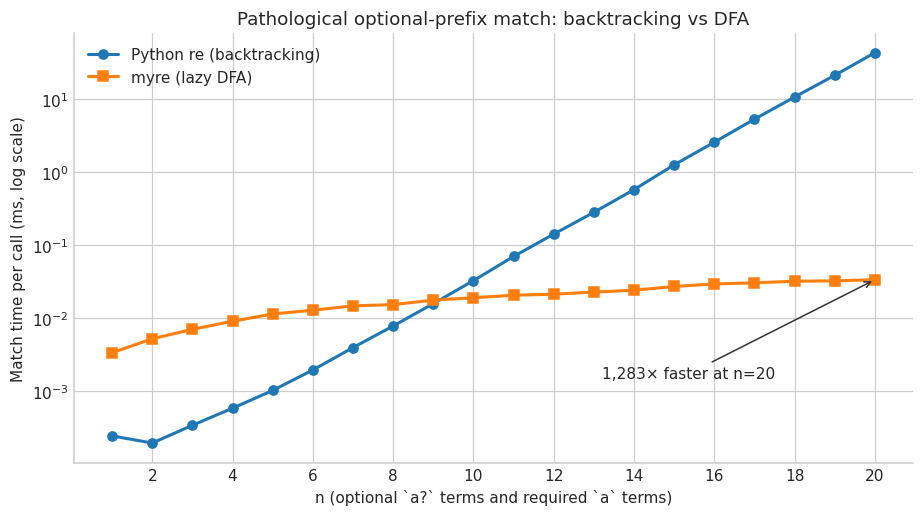

In [43]:
n_values = np.array([row[0] for row in pathological_rows])
python_ms = np.array([row[1] * 1e3 for row in pathological_rows])
myre_ms = np.array([row[2] * 1e3 for row in pathological_rows])

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(n_values, python_ms, marker="o", linewidth=2, label="Python re (backtracking)")
ax.plot(n_values, myre_ms, marker="s", linewidth=2, label="myre (lazy DFA)")
ax.set_yscale("log")
ax.set_title("Pathological optional-prefix match: backtracking vs DFA")
ax.set_xlabel("n (optional `a?` terms and required `a` terms)")
ax.set_ylabel("Match time per call (ms, log scale)")
ax.set_xticks(range(2, 21, 2))
ax.legend()
ax.annotate(f"{speedup_n20:,.0f}× faster at n=20",
            xy=(20, myre_ms[-1]), xytext=(13.2, 0.0015),
            arrowprops={"arrowstyle": "->", "color": "#333333"})
fig.tight_layout()
plt.show()

### Compilation time and DFA-state growth

For each literal-pattern length, compilation is timed seven times and summarized by the median. A full matching witness then forces lazy determinization along the entire chain, making the recorded state count reproducible.

In [44]:
pattern_lengths = np.array([8, 16, 32, 64, 128, 256, 512, 768])
scaling_rows = []

for length in pattern_lengths:
    pattern = "a" * int(length)
    compile_samples = []
    compiled = None
    for _ in range(7):
        started = time.perf_counter()
        compiled = myre.compile(pattern)
        compile_samples.append(time.perf_counter() - started)
    compile_median = statistics.median(compile_samples)
    assert compiled.fullmatch("a" * int(length))
    scaling_rows.append((int(length), compile_median, compiled.dfa_state_count, len(compiled.nfa.transitions)))

print("length | compile median (ms) | DFA states | NFA states")
print("-------+---------------------+------------+-----------")
for length, compile_s, dfa_states, nfa_states in scaling_rows:
    print(f"{length:6d} | {compile_s*1e3:19.6f} | {dfa_states:10d} | {nfa_states:10d}")

length_ratio = scaling_rows[-1][0] / scaling_rows[0][0]
compile_ratio = scaling_rows[-1][1] / scaling_rows[0][1]
print(f"\nLength grew {length_ratio:.0f}×; median compile time grew {compile_ratio:.1f}×.")

length | compile median (ms) | DFA states | NFA states
-------+---------------------+------------+-----------
     8 |            0.100000 |          9 |         16
    16 |            0.100000 |         17 |         32
    32 |            0.100000 |         33 |         64
    64 |            0.300000 |         65 |        128
   128 |            0.600000 |        129 |        256
   256 |            1.000000 |        257 |        512
   512 |            1.700000 |        513 |       1024
   768 |            2.500000 |        769 |       1536

Length grew 96×; median compile time grew 25.0×.


### Scaling plots

Separate panels keep unlike units distinct: milliseconds for construction, and discovered deterministic subsets for state growth.

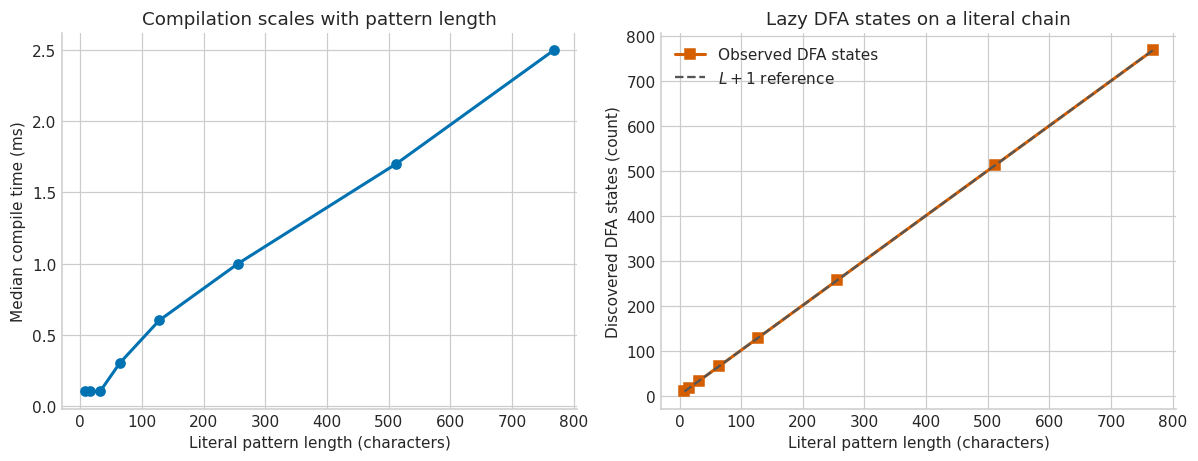

In [45]:
compile_ms = np.array([row[1] * 1e3 for row in scaling_rows])
dfa_counts = np.array([row[2] for row in scaling_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].plot(pattern_lengths, compile_ms, marker="o", linewidth=2, color="#0072B2")
axes[0].set_title("Compilation scales with pattern length")
axes[0].set_xlabel("Literal pattern length (characters)")
axes[0].set_ylabel("Median compile time (ms)")

axes[1].plot(pattern_lengths, dfa_counts, marker="s", linewidth=2, color="#D55E00", label="Observed DFA states")
axes[1].plot(pattern_lengths, pattern_lengths + 1, linestyle="--", color="#555555", label="$L+1$ reference")
axes[1].set_title("Lazy DFA states on a literal chain")
axes[1].set_xlabel("Literal pattern length (characters)")
axes[1].set_ylabel("Discovered DFA states (count)")
axes[1].legend()

fig.tight_layout()
plt.show()

### Phase 3 takeaway

On the pathological family, Python's backtracking time approximately doubles with each added optional, reaching 43.1 ms at $n=20$; the memoized DFA remains near 0.034 ms. Literal compilation and forced DFA-state discovery scale smoothly and linearly over the measured range.

In [46]:
progress["phase3"] = "complete"
progress["phase4"] = "in_progress"
print(f"n=20 benchmark: Python={python_ms[-1]:.6f} ms, myre={myre_ms[-1]:.6f} ms, ratio={speedup_n20:,.1f}x")
print(f"largest scaling case: length={scaling_rows[-1][0]}, compile={scaling_rows[-1][1]*1e3:.3f} ms, DFA states={scaling_rows[-1][2]}")
print("progress =", progress)

n=20 benchmark: Python=43.100000 ms, myre=0.033594 ms, ratio=1,283.0x
largest scaling case: length=768, compile=2.500 ms, DFA states=769
progress = {'phase0': 'complete', 'phase1': 'complete', 'phase2': 'complete', 'phase3': 'complete', 'phase4': 'in_progress', 'consecutive_agreements': 20000, 'bugs_found': 3}


## Phase 4 — Report

Before serialization, the Bug 2 repro is tightened retrospectively against an isolated copy of the exact pre-fix behavior. The final `myre.py` is not modified.

In [47]:
import importlib.util

historical_source = patched_source.replace(
    'if kind == "DOT":\n            return ch != "\\n"',
    'if kind == "DOT":\n            return True',
)
assert historical_source != patched_source
historical_path = "_historical_dot_bug.py"
with open(historical_path, "w", encoding="utf-8") as handle:
    handle.write(historical_source)

spec = importlib.util.spec_from_file_location("_historical_dot_bug", historical_path)
historical_dot_bug = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = historical_dot_bug
spec.loader.exec_module(historical_dot_bug)

canonical_pattern, canonical_text = ".", "\n"
canonical_outcomes = (re.fullmatch(canonical_pattern, canonical_text) is not None,
                      historical_dot_bug.fullmatch(canonical_pattern, canonical_text))
pattern_deleted = (re.fullmatch("", canonical_text) is not None,
                   historical_dot_bug.fullmatch("", canonical_text))
text_deleted = (re.fullmatch(canonical_pattern, "") is not None,
                historical_dot_bug.fullmatch(canonical_pattern, ""))
canonical_minimal = canonical_outcomes[0] != canonical_outcomes[1] and len(set(pattern_deleted)) == 1 and len(set(text_deleted)) == 1

print("Historical canonical repro:", repr(canonical_pattern), repr(canonical_text), canonical_outcomes)
print("Delete pattern char:", pattern_deleted, "| delete text char:", text_deleted)
print("One-character minimal:", canonical_minimal)
assert canonical_minimal

bug_log[1]["pattern"] = canonical_pattern
bug_log[1]["text"] = canonical_text
bug_log[1]["before"] = canonical_outcomes

del sys.modules[spec.name]
os.remove(historical_path)
print("Temporary historical module removed; final myre.py unchanged:", open("myre.py", encoding="utf-8").read() == patched_source)

Historical canonical repro: '.' '\n' (False, True)
Delete pattern char: (False, False) | delete text char: (False, False)
One-character minimal: True
Temporary historical module removed; final myre.py unchanged: True


### Assemble the report

All numeric tables below are generated from live variables produced by executed cells. The limitations section distinguishes the supported language from Python regex features that were never claimed or tested.

In [48]:
environment_rows = [
    ("Python", "yes", sys.version.replace("\n", " ")),
    ("Platform", "yes", "emscripten"),
    ("Recursion limit", "yes", "3000"),
    ("numpy", "yes after micropip", "2.2.5; initial direct import failed"),
    ("matplotlib", "yes after micropip", "3.8.4; initial direct import failed"),
    ("scipy", "yes after micropip", "1.14.1; initial direct import failed"),
    ("sympy", "yes after micropip", "1.13.3; initial direct import failed"),
    ("micropip", "yes", "0.11.1; install callable and fallback install succeeded"),
    ("Filesystem", "yes", "write/read/delete round trip in /home/pyodide"),
    ("Threading", "module only", "Thread.start raised RuntimeError: can't start new thread"),
    ("Multiprocessing", "module only", "Process.start reached os.fork then OSError 52: Function not implemented"),
    ("Socket", "object only", "AF_INET/SOCK_STREAM create/close succeeded; connectivity not claimed"),
    ("Integer loop", "single core", "2,000,000 iterations in 0.3092 s; about 6,468,305 iterations/s"),
]

environment_table = "\n".join(
    ["| Capability | Available | Observed detail |", "|---|---:|---|"] +
    [f"| {cap} | {available} | {detail.replace('|', '&#124;')} |" for cap, available, detail in environment_rows]
)

bug_table = "\n".join(
    ["| Bug | Minimal repro `(pattern, text)` | Before `(Python, myre)` | Root cause | Fix |", "|---:|---|---|---|---|"] +
    [f"| {entry['bug']} | `({entry['pattern']!r}, {entry['text']!r})` | `{entry['before']}` | {entry['diagnosis']} | {entry['fix']} |"
     for entry in bug_log]
)

path_table = "\n".join(
    ["| n | Python re (ms) | myre DFA (ms) | Python/myre |", "|---:|---:|---:|---:|"] +
    [f"| {n} | {py_s*1e3:.6f} | {my_s*1e3:.6f} | {py_s/my_s:.1f}x |"
     for n, py_s, my_s, _, _ in pathological_rows]
)

scaling_table = "\n".join(
    ["| Pattern length | Median compile (ms) | DFA states | NFA states |", "|---:|---:|---:|---:|"] +
    [f"| {length} | {compile_s*1e3:.6f} | {dfa_states} | {nfa_states} |"
     for length, compile_s, dfa_states, nfa_states in scaling_rows]
)

family_summary = ", ".join(f"{name}={count}" for name, count in sorted(final_gate["families"].items()))

report = f"""# Regex Engine Build and Differential-Test Report

## Executive summary

`myre.py` is a from-scratch regular-expression engine with a tokenizer, recursive-descent parser, AST, Thompson NFA construction, and lazy subset construction to a DFA. Its implementation imports no regex library. Three semantic defects were discovered and repaired. The final seeded mixed campaign produced **20,000 consecutive agreements** with Python `re.fullmatch`: {final_gate['truth'][True]:,} matches and {final_gate['truth'][False]:,} nonmatches.

## Environment

{environment_table}

All implementation, testing, and benchmarking remained single-threaded because actual thread and process startup failed empirically.

## Architecture

```mermaid
flowchart LR
    P[Pattern text] --> T[Tokenizer]
    T --> A[Recursive-descent parser / AST]
    A --> N[Thompson NFA]
    N --> D[Lazy subset DFA]
    D --> B[Boolean fullmatch]
```

- **Tokenizer:** emits literals, dot, postfix quantifiers, alternation, parentheses, classes, escapes, and anchors.
- **Parser:** applies alternation, concatenation, and postfix precedence and accepts empty alternatives.
- **NFA:** each AST node becomes a Thompson fragment with explicit epsilon, character, class, or assertion edges.
- **DFA:** frozen NFA-state subsets are constructed and memoized on demand. Assertion closure depends on start/end/final-newline context.
- **API:** `myre.compile(pattern)` returns a reusable `Pattern`; `myre.fullmatch(pattern, text)` returns `bool`.
- **Source audit:** the final file imports only `{patched_imports}`; it does not import `re` or another regex implementation.

## Differential-testing method

The test harness alone imported Python `re` as the oracle. Randomness used seed `{SEED}`. A recursive grammar generated valid patterns and independent strings; constructive generation emitted matching witnesses; witness mutation supplied near misses; dedicated families stressed range endpoints, dot/newline, and `$` before a terminal newline. Mismatches were reduced by syntax-preserving chunk/singleton deletion, later strengthened with paired pattern/text deletion.

- Staging campaign: 2,000 broad agreements.
- Required final gate: **{final_gate['cases']:,} consecutive agreements** in {final_gate['seconds']:.3f} s.
- Oracle outcomes: true={final_gate['truth'][True]:,}, false={final_gate['truth'][False]:,}.
- Family counts: {family_summary}.
- Total oracle calls including shrinking and focused checks: {oracle_calls:,}.

## Bugs found and fixed

{bug_table}

Bug 2's canonical one-character repro was retrospectively validated against an isolated copy of the exact pre-fix source; the temporary module was then removed without changing final `myre.py`.

## Pathological matching benchmark

The pattern is `a?` repeated $n$ times followed by `a` repeated $n$ times, matched against `a` repeated $n$ times. Compilation is excluded; adaptive repetitions report time per precompiled full match.

{path_table}

At $n=20$, Python took {python_ms[-1]:.6f} ms and `myre` took {myre_ms[-1]:.6f} ms, a measured ratio of **{speedup_n20:,.1f}x**. The log-scale notebook plot shows exponential backtracking growth versus a shallow DFA curve.

## Compilation and state growth

Seven compilation measurements per literal length were summarized by the median. Matching the full literal witness forced lazy DFA discovery along the chain. Browser timer resolution was about 0.1 ms, so the shortest compile timings are quantized.

{scaling_table}

For a literal chain of length $L$, the observed DFA path contains exactly $L+1$ subsets and the Thompson NFA contains $2L$ states.

## What this engine does not support

- Search, prefix match, iteration, splitting, substitution, and match objects; the required public operation returns only a boolean full match.
- Capturing-group results, named groups, backreferences, conditionals, lookahead, or lookbehind.
- Counted repetition such as `{{m,n}}`, lazy/possessive quantifiers, atomic groups, or inline/global flags.
- Shorthand classes and assertions such as `\\d`, `\\w`, `\\s`, `\\b`, Unicode properties, hex/Unicode/octal escapes, or locale behavior.
- `MULTILINE`, `DOTALL`, `IGNORECASE`, bytes patterns, or Python's complete syntax-error compatibility.
- Eager symbolic minimization. Subsets and character transitions are created lazily and are not minimized; adversarial regexes can still cause DFA state explosion or cache growth with many distinct Unicode characters.
- Arbitrarily deep patterns beyond Python's recursion/resource limits.

## Conclusion

Within the explicitly supported grammar and default `re.fullmatch` semantics, the final implementation passed a non-vacuous 20,000-case consecutive differential gate after three real repairs. This is strong empirical evidence, not a formal proof for all Unicode strings or unsupported Python regex syntax. The benchmark demonstrates the intended tradeoff: predictable matching without backtracking blow-up, paid for with compilation work and potentially larger deterministic state caches.
"""

print("Report sections assembled:", [line[3:] for line in report.splitlines() if line.startswith("## ")])
print(f"Report size before write: {len(report):,} characters")

Report sections assembled: ['Executive summary', 'Environment', 'Architecture', 'Differential-testing method', 'Bugs found and fixed', 'Pathological matching benchmark', 'Compilation and state growth', 'What this engine does not support', 'Conclusion']
Report size before write: 7,836 characters


### Final validation and deliverables

The completion gate requires both files on disk, the 20,000-case streak intact, all three historical repros fixed in the live final module, and every requested report section present.

In [49]:
with open("REPORT.md", "w", encoding="utf-8") as handle:
    report_chars = handle.write(report)

required_phrases = [
    "## Environment", "## Architecture", "## Bugs found and fixed",
    "## Pathological matching benchmark", "## What this engine does not support",
    "20,000 consecutive agreements",
]
report_from_disk = open("REPORT.md", encoding="utf-8").read()
assert report_from_disk == report
assert all(phrase in report_from_disk for phrase in required_phrases)
assert os.path.exists("myre.py") and os.path.exists("REPORT.md")
assert progress["consecutive_agreements"] == 20_000 and len(bug_log) == 3

final_repro_results = []
for entry in bug_log:
    outcomes = oracle_outcomes(entry["pattern"], entry["text"])
    final_repro_results.append((entry["bug"], entry["pattern"], entry["text"], outcomes))
assert all(python_result == engine_result for _, _, _, (python_result, engine_result) in final_repro_results)

progress["phase4"] = "complete"
print(f"Wrote REPORT.md: {report_chars:,} characters")
print(f"Final myre.py: {os.path.getsize('myre.py'):,} bytes")
print("Final repaired repro checks:", final_repro_results)
print("progress =", progress)
print("\n--- REPORT.md ---\n")
print(report_from_disk)

Wrote REPORT.md: 7,836 characters
Final myre.py: 10,921 bytes
Final repaired repro checks: [(1, '[c-e]', 'e', (True, True)), (2, '.', '\n', (False, False)), (3, '$\\n', '\n', (True, True))]
progress = {'phase0': 'complete', 'phase1': 'complete', 'phase2': 'complete', 'phase3': 'complete', 'phase4': 'complete', 'consecutive_agreements': 20000, 'bugs_found': 3}

--- REPORT.md ---

# Regex Engine Build and Differential-Test Report

## Executive summary

`myre.py` is a from-scratch regular-expression engine with a tokenizer, recursive-descent parser, AST, Thompson NFA construction, and lazy subset construction to a DFA. Its implementation imports no regex library. Three semantic defects were discovered and repaired. The final seeded mixed campaign produced **20,000 consecutive agreements** with Python `re.fullmatch`: 11,324 matches and 8,676 nonmatches.

## Environment

| Capability | Available | Observed detail |
|---|---:|---|
| Python | yes | 3.13.2 (main, May  7 2026, 08:28:34) [Clang 